# EDA — viajes de taxi amarillo de NYC (enero de 2024)

Análisis exploratorio breve del dataset **silver** producido por el pipeline de limpieza. El objetivo es describir qué datos tenemos y generar figuras listas para reutilizar en el informe.

## tl;dr

- El dataset limpio contiene **2,831,486 viajes**, equivalentes al **95.51 %** de las filas originales.
- El viaje típico (mediana) dura **11.72 min**, recorre **1.70 mi** y registra un total de **USD 20.16**.
- La demanda se concentra en Manhattan y presenta dos franjas de alta actividad: mediodía y tarde-noche.
- Duración y distancia tienen cola derecha; esto respalda la transformación `log1p` usada antes de K-means.

> Las cifras y figuras se calculan en las celdas siguientes; no dependen de valores editados manualmente.

## Contexto y método

**Fuente.** NYC Taxi & Limousine Commission (TLC), Yellow Taxi Trip Records, enero de 2024.  
**Unidad de análisis.** Un viaje válido de taxi amarillo.  
**Archivo analizado.** `data/silver/yellow_2024-01.parquet`.  
**Limpieza.** Se excluyen viajes fuera del mes, duraciones/distancias/velocidades implausibles, montos no positivos y zonas no ubicables; el detalle está en `reports/limpieza_yellow_2024-01.md`.

### Supuestos clave

- Los timestamps representan hora local de Nueva York, tal como los publica TLC.
- Los importes están en dólares estadounidenses y las distancias en millas.
- Los percentiles limitan únicamente los ejes de las figuras de distribución; **no eliminan filas adicionales**.
- Para los gráficos de dispersión se usa una muestra reproducible, solo para acelerar la visualización.

## Datos

### 1. Configuración y carga reproducible

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import polars as pl
from IPython.display import Markdown, display

# Permite ejecutar desde tp/ o desde tp/notebooks/.
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

SILVER_PATH = ROOT / "data/silver/yellow_2024-01.parquet"
ZONES_PATH = ROOT / "data/bronze/taxi_zone_lookup.csv"
REPORT_PATH = ROOT / "reports/limpieza_yellow_2024-01.json"

for path in (SILVER_PATH, ZONES_PATH, REPORT_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Falta {path}. Ejecuta `uv run nyc-tlc all` desde tp/.")

COLORS = {
    "blue": "#2457A7",
    "gold": "#D89B20",
    "orange": "#D96C32",
    "olive": "#708238",
    "pink": "#B9577A",
    "ink": "#25313C",
    "grid": "#D9DEE5",
}
plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "axes.edgecolor": COLORS["ink"],
    "text.color": COLORS["ink"],
    "axes.labelcolor": COLORS["ink"],
    "xtick.color": COLORS["ink"],
    "ytick.color": COLORS["ink"],
    "grid.color": COLORS["grid"],
    "grid.alpha": 0.65,
})

trips = pl.scan_parquet(SILVER_PATH).with_columns(
    ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
        .dt.total_seconds() / 60).alias("duration_min"),
    pl.col("tpep_pickup_datetime").dt.hour().alias("pickup_hour"),
    (pl.col("tpep_pickup_datetime").dt.weekday() - 1).alias("weekday"),
    pl.col("tpep_pickup_datetime").dt.date().alias("pickup_date"),
)
zones = pl.read_csv(ZONES_PATH).select("LocationID", "Borough", "Zone")
report = json.loads(REPORT_PATH.read_text())

print(f"Silver: {SILVER_PATH.relative_to(ROOT)}")
print(f"Filas: {report['filas']['silver']:,}")

Silver: data/silver/yellow_2024-01.parquet
Filas: 2,831,486


### 2. Esquema y cobertura

In [2]:
schema_rows = pl.DataFrame({
    "columna": list(trips.collect_schema().names()),
    "tipo": [str(dtype) for dtype in trips.collect_schema().dtypes()],
})

coverage = trips.select(
    pl.len().alias("viajes"),
    pl.col("tpep_pickup_datetime").min().alias("primer_pickup"),
    pl.col("tpep_pickup_datetime").max().alias("ultimo_pickup"),
    pl.sum_horizontal(pl.all().null_count()).alias("nulos_totales"),
).collect()

display(Markdown("**Cobertura del dataset silver**"))
display(coverage)
display(Markdown(f"**Esquema ({schema_rows.height} columnas)**"))
display(schema_rows)

**Cobertura del dataset silver**

viajes,primer_pickup,ultimo_pickup,nulos_totales
u32,datetime[ns],datetime[ns],u32
2831486,2024-01-01 00:00:00,2024-01-31 23:59:55,571555


**Esquema (23 columnas)**

columna,tipo
str,str
"""VendorID""","""Int32"""
"""tpep_pickup_datetime""","""Datetime(time_unit='ns', time_…"
"""tpep_dropoff_datetime""","""Datetime(time_unit='ns', time_…"
"""passenger_count""","""Int64"""
"""trip_distance""","""Float64"""
…,…
"""Airport_fee""","""Float64"""
"""duration_min""","""Float64"""
"""pickup_hour""","""Int8"""


> Los nulos restantes pertenecen principalmente a campos opcionales que el pipeline y el modelo no utilizan (por ejemplo, atributos de Flex Fare). Las columnas requeridas para el análisis sí fueron validadas durante la limpieza.

### 3. Resumen de variables principales

In [3]:
summary = trips.select(
    pl.len().alias("viajes"),
    pl.col("duration_min").median().alias("duracion_mediana_min"),
    pl.col("duration_min").quantile(0.90).alias("duracion_p90_min"),
    pl.col("trip_distance").median().alias("distancia_mediana_mi"),
    pl.col("trip_distance").quantile(0.90).alias("distancia_p90_mi"),
    pl.col("total_amount").median().alias("total_mediano_usd"),
    pl.col("total_amount").quantile(0.90).alias("total_p90_usd"),
).collect().with_columns(pl.exclude("viajes").round(2))
summary

viajes,duracion_mediana_min,duracion_p90_min,distancia_mediana_mi,distancia_p90_mi,total_mediano_usd,total_p90_usd
u32,f64,f64,f64,f64,f64,f64
2831486,11.72,28.72,1.7,8.4,20.16,51.6


## Resultados

### 4. Efecto de la limpieza

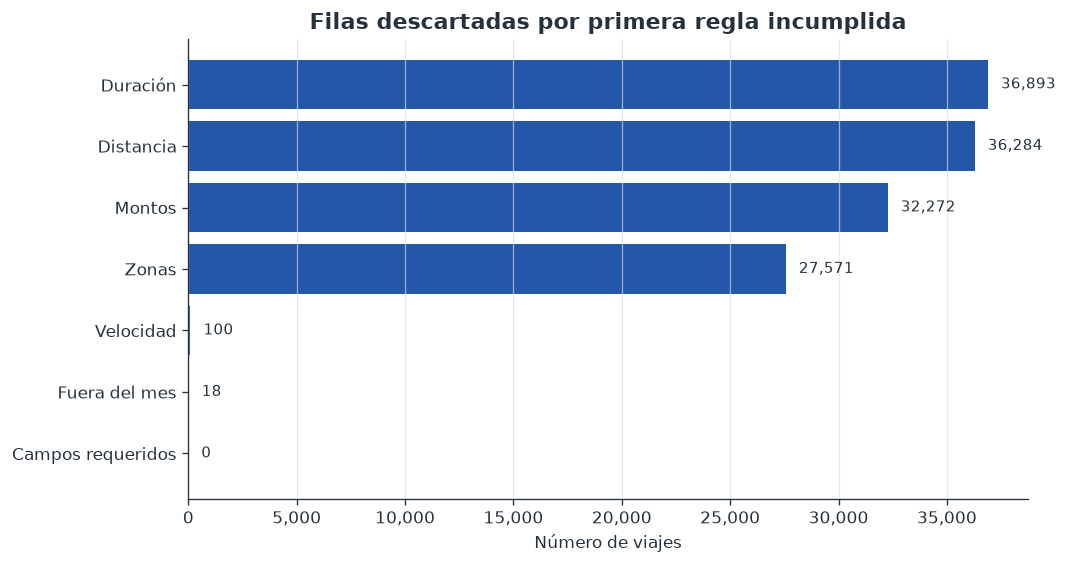

Se conservaron 95.51% de las filas originales (2,831,486 viajes).


In [4]:
rule_labels = {
    "requeridos": "Campos requeridos",
    "mes": "Fuera del mes",
    "duracion": "Duración",
    "distancia": "Distancia",
    "velocidad": "Velocidad",
    "montos": "Montos",
    "zonas": "Zonas",
}
cleaning = pl.DataFrame([
    {"regla": rule_labels[row["regla"]], "descartados": row["descartados"]}
    for row in report["reglas"]
]).sort("descartados")

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(cleaning["regla"], cleaning["descartados"], color=COLORS["blue"])
ax.set_title("Filas descartadas por primera regla incumplida")
ax.set_xlabel("Número de viajes")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="x")
for i, value in enumerate(cleaning["descartados"]):
    ax.text(value + 600, i, f"{value:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

retained = report["filas"]["silver"] / report["filas"]["bronze"]
print(f"Se conservaron {retained:.2%} de las filas originales ({report['filas']['silver']:,} viajes).")

**Lectura.** La mayor parte de las exclusiones proviene de duraciones y distancias implausibles. Como las reglas se aplican en cascada, cada fila aparece una sola vez y las barras son aditivas.

### 5. Distribuciones de duración, distancia e importe

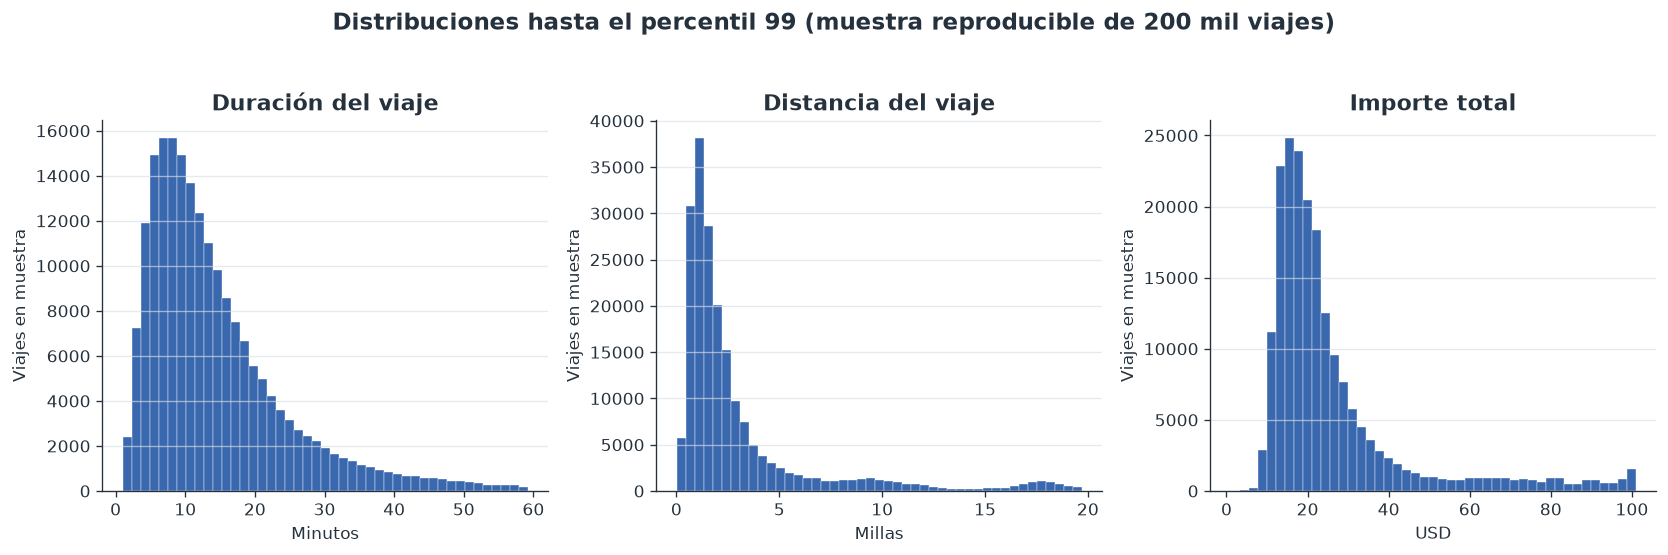

{'duration_p99': 59.18, 'distance_p99': 19.7, 'amount_p99': 100.94}


In [5]:
distribution_limits = trips.select(
    pl.col("duration_min").quantile(0.99).alias("duration_p99"),
    pl.col("trip_distance").quantile(0.99).alias("distance_p99"),
    pl.col("total_amount").quantile(0.99).alias("amount_p99"),
).collect().row(0, named=True)

sample = trips.select("duration_min", "trip_distance", "total_amount").collect().sample(
    n=200_000, seed=2024, shuffle=True
)

variables = [
    ("duration_min", "Duración del viaje", "Minutos", distribution_limits["duration_p99"]),
    ("trip_distance", "Distancia del viaje", "Millas", distribution_limits["distance_p99"]),
    ("total_amount", "Importe total", "USD", distribution_limits["amount_p99"]),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, (column, title, unit, upper) in zip(axes, variables):
    values = sample.filter(pl.col(column) <= upper)[column].to_numpy()
    ax.hist(values, bins=45, color=COLORS["blue"], alpha=0.9, edgecolor="white", linewidth=0.25)
    ax.set_title(title)
    ax.set_xlabel(unit)
    ax.set_ylabel("Viajes en muestra")
    ax.grid(axis="y")
fig.suptitle("Distribuciones hasta el percentil 99 (muestra reproducible de 200 mil viajes)", y=1.04, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print({key: round(value, 2) for key, value in distribution_limits.items()})

**Lectura.** Las tres variables tienen asimetría positiva: muchos viajes cortos y una cola de viajes largos/costosos. Mostrar hasta p99 permite ver el cuerpo de la distribución sin borrar los extremos del dataset.

### 6. Demanda por hora y día de la semana

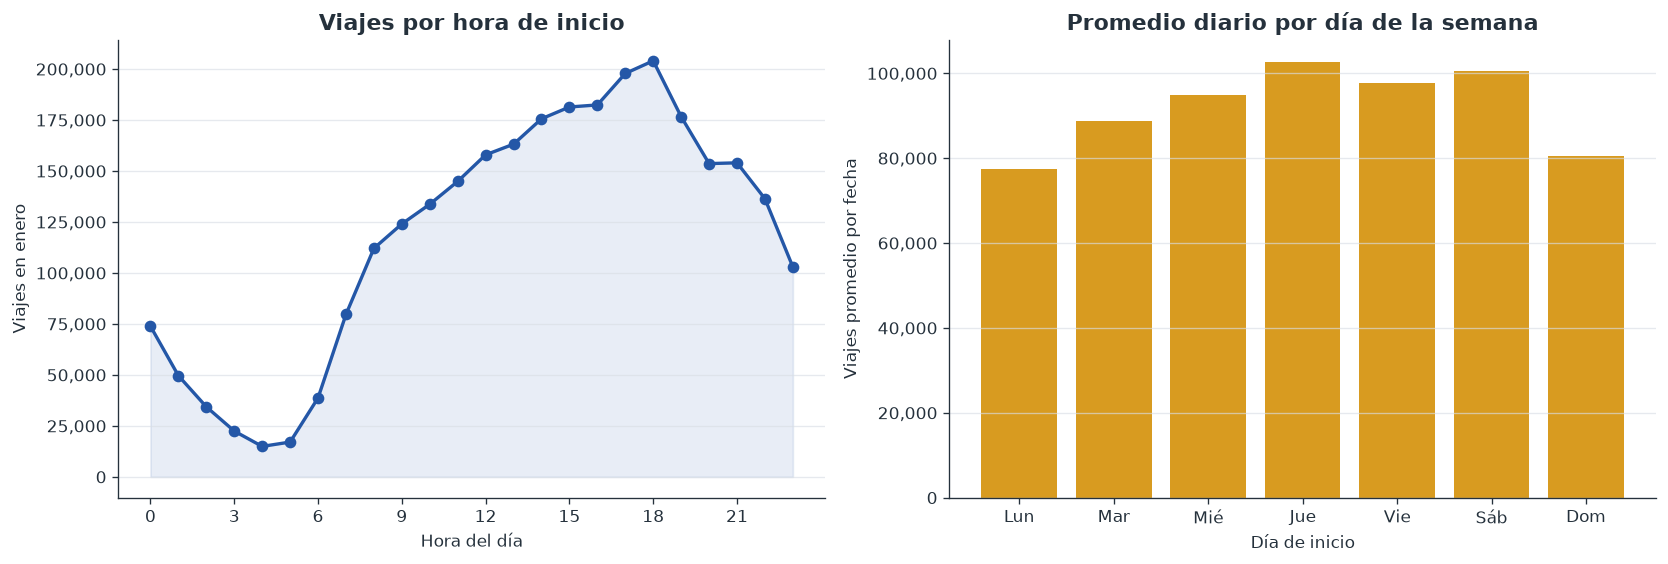

Hora con más viajes: 18:00 (204,048).
Día con mayor promedio diario: Jue (102,718 viajes por fecha).


In [6]:
hourly = trips.group_by("pickup_hour").len().sort("pickup_hour").collect()
weekday_names = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
by_weekday = (
    trips.group_by("pickup_date", "weekday").len()
    .group_by("weekday").agg(pl.col("len").mean().alias("viajes_promedio"))
    .sort("weekday").collect()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(hourly["pickup_hour"], hourly["len"], color=COLORS["blue"], marker="o", linewidth=2)
axes[0].fill_between(hourly["pickup_hour"], hourly["len"], color=COLORS["blue"], alpha=0.10)
axes[0].set_title("Viajes por hora de inicio")
axes[0].set_xlabel("Hora del día")
axes[0].set_ylabel("Viajes en enero")
axes[0].set_xticks(range(0, 24, 3))
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
axes[0].grid(axis="y")

axes[1].bar(weekday_names, by_weekday["viajes_promedio"], color=COLORS["gold"])
axes[1].set_title("Promedio diario por día de la semana")
axes[1].set_xlabel("Día de inicio")
axes[1].set_ylabel("Viajes promedio por fecha")
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
axes[1].grid(axis="y")
plt.tight_layout()
plt.show()

peak_hour = hourly.sort("len", descending=True).row(0, named=True)
peak_day = by_weekday.sort("viajes_promedio", descending=True).row(0, named=True)
print(f"Hora con más viajes: {peak_hour['pickup_hour']:02d}:00 ({peak_hour['len']:,}).")
print(f"Día con mayor promedio diario: {weekday_names[peak_day['weekday']]} "
      f"({peak_day['viajes_promedio']:,.0f} viajes por fecha).")

**Lectura.** La actividad cae durante la madrugada y aumenta desde la mañana. El perfil horario y semanal justifica conservar la representación cíclica de hora y día en las features del modelo.

### 7. Distribución espacial de los orígenes

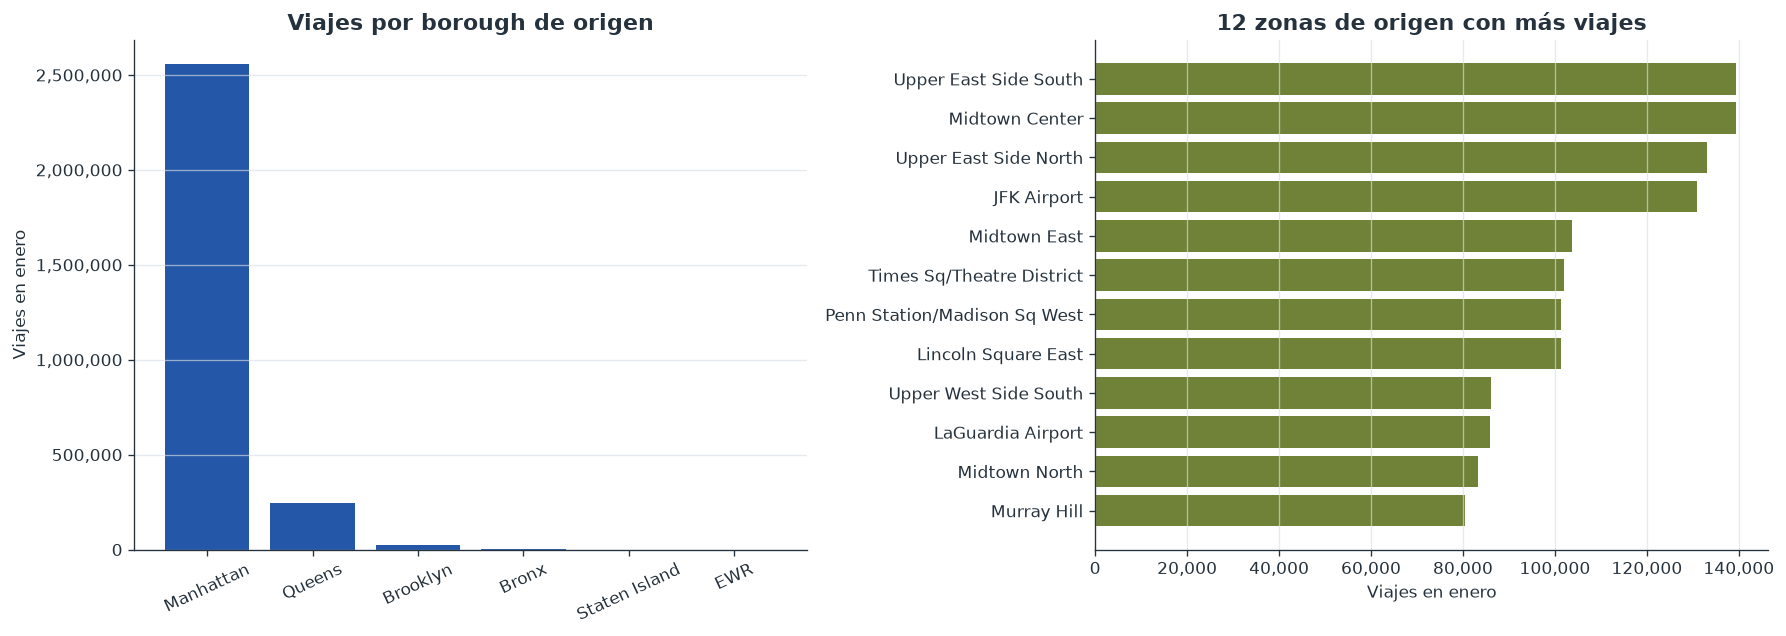

Borough,len,porcentaje
str,u32,f64
"""Manhattan""",2556490,90.29
"""Queens""",247299,8.73
"""Brooklyn""",21968,0.78
"""Bronx""",5689,0.2
"""Staten Island""",29,0.0
"""EWR""",11,0.0


In [7]:
pickup_geo = (
    trips.group_by("PULocationID").len()
    .collect()
    .join(zones, left_on="PULocationID", right_on="LocationID", how="left")
)
boroughs = pickup_geo.group_by("Borough").agg(pl.col("len").sum()).sort("len", descending=True)
top_zones = pickup_geo.sort("len", descending=True).head(12).sort("len")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))
axes[0].bar(boroughs["Borough"], boroughs["len"], color=COLORS["blue"])
axes[0].set_title("Viajes por borough de origen")
axes[0].set_ylabel("Viajes en enero")
axes[0].tick_params(axis="x", rotation=25)
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
axes[0].grid(axis="y")

axes[1].barh(top_zones["Zone"], top_zones["len"], color=COLORS["olive"])
axes[1].set_title("12 zonas de origen con más viajes")
axes[1].set_xlabel("Viajes en enero")
axes[1].xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
axes[1].grid(axis="x")
plt.tight_layout()
plt.show()

boroughs.with_columns((pl.col("len") / pl.col("len").sum() * 100).round(2).alias("porcentaje"))

**Lectura.** Los orígenes se concentran fuertemente en Manhattan. Los `LocationID` se usan solo para unir con el catálogo de zonas; no se interpretan como una escala numérica ni entran al K-means.

### 8. Relación entre distancia y duración

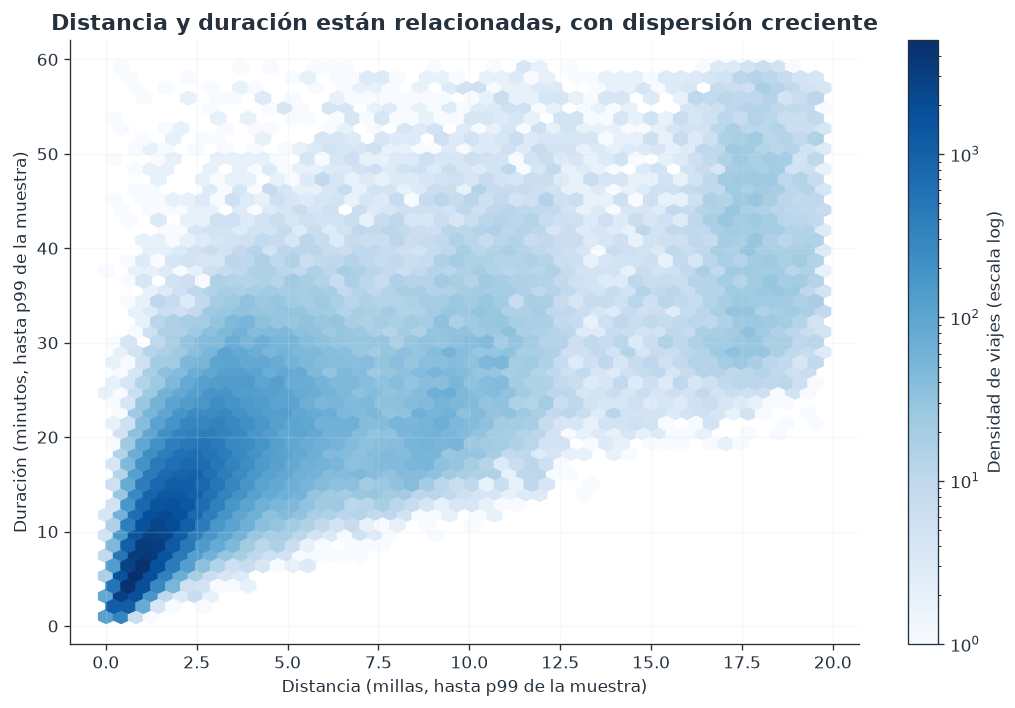

Correlación de Pearson en la muestra visualizada: 0.790


In [8]:
relation_sample = trips.select("trip_distance", "duration_min").collect().sample(
    n=150_000, seed=2024, shuffle=True
)
distance_limit = relation_sample["trip_distance"].quantile(0.99)
duration_limit = relation_sample["duration_min"].quantile(0.99)
relation_sample = relation_sample.filter(
    (pl.col("trip_distance") <= distance_limit) & (pl.col("duration_min") <= duration_limit)
)

fig, ax = plt.subplots(figsize=(9, 6))
hexbin = ax.hexbin(
    relation_sample["trip_distance"], relation_sample["duration_min"],
    gridsize=48, mincnt=1, bins="log", cmap="Blues"
)
ax.set_title("Distancia y duración están relacionadas, con dispersión creciente")
ax.set_xlabel("Distancia (millas, hasta p99 de la muestra)")
ax.set_ylabel("Duración (minutos, hasta p99 de la muestra)")
colorbar = fig.colorbar(hexbin, ax=ax)
colorbar.set_label("Densidad de viajes (escala log)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

correlation = relation_sample.select(pl.corr("trip_distance", "duration_min")).item()
print(f"Correlación de Pearson en la muestra visualizada: {correlation:.3f}")

**Lectura.** La asociación es positiva, pero una misma distancia puede tomar tiempos distintos por tráfico, ruta y ubicación. Por eso ambas dimensiones aportan información al agrupamiento.

## Conclusiones

1. El conjunto limpio mantiene más de 2.8 millones de observaciones y supera ampliamente el mínimo del proyecto.
2. La demanda no es uniforme: varía de forma marcada por hora, día y zona de origen.
3. Duración, distancia e importe presentan colas derechas; las transformaciones logarítmicas de duración y distancia usadas en gold son razonables para K-means.
4. La relación distancia–duración es clara pero no determinista, de modo que conservar ambas variables puede separar patrones operativos distintos.

**Limitación.** Este EDA describe un solo mes y una sola flota; no permite concluir estacionalidad anual ni generalizar a taxis verdes o vehículos de alquiler.